In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append("..")

In [2]:
import torch
from torch.utils.data import DataLoader
import torch.fft

import matplotlib.pyplot as plt

import numpy as np  

import time

import scipy.sparse as sp
import scipy.sparse.linalg as spla

from architectures import PINO2D
from generators import RibWaveguideDataset, ChannelDataset

torch.Size([1, 5, 199, 199]) torch.Size([1, 8])


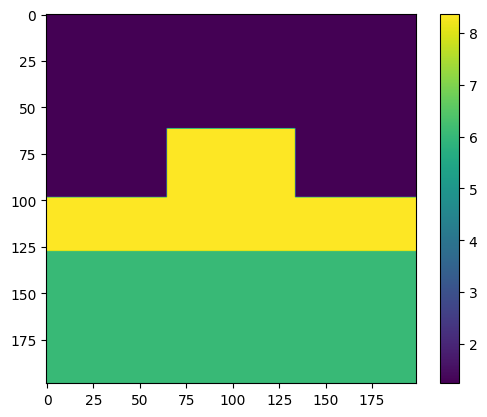

In [5]:
ds = RibWaveguideDataset(n_dataset=1, device='cpu')
dl = DataLoader(ds, batch_size=1, shuffle=True)
for batch in dl:
    print(batch[0].shape, batch[1].shape)
    plt.imshow(batch[0][0, 2, :, :].T.flip((0,)))
    plt.colorbar()

In [18]:
torch.manual_seed(42)
train_dataset = RibWaveguideDataset(n_dataset=640000, stochastic=False, device='cpu', dx=1/20, dy=1/20)
val_datasest = RibWaveguideDataset(n_dataset=1024, stochastic=False, device='cpu', dx=1/20, dy=1/20)

In [19]:
rib_features = torch.tensor(train_dataset.dataset_features)
rib_features[:, 0] = 2 * np.pi / rib_features[:, 0]

In [20]:
rib_test_features = torch.tensor(val_datasest.dataset_features)
rib_test_features[:, 0] = 2 * np.pi / rib_test_features[:, 0]

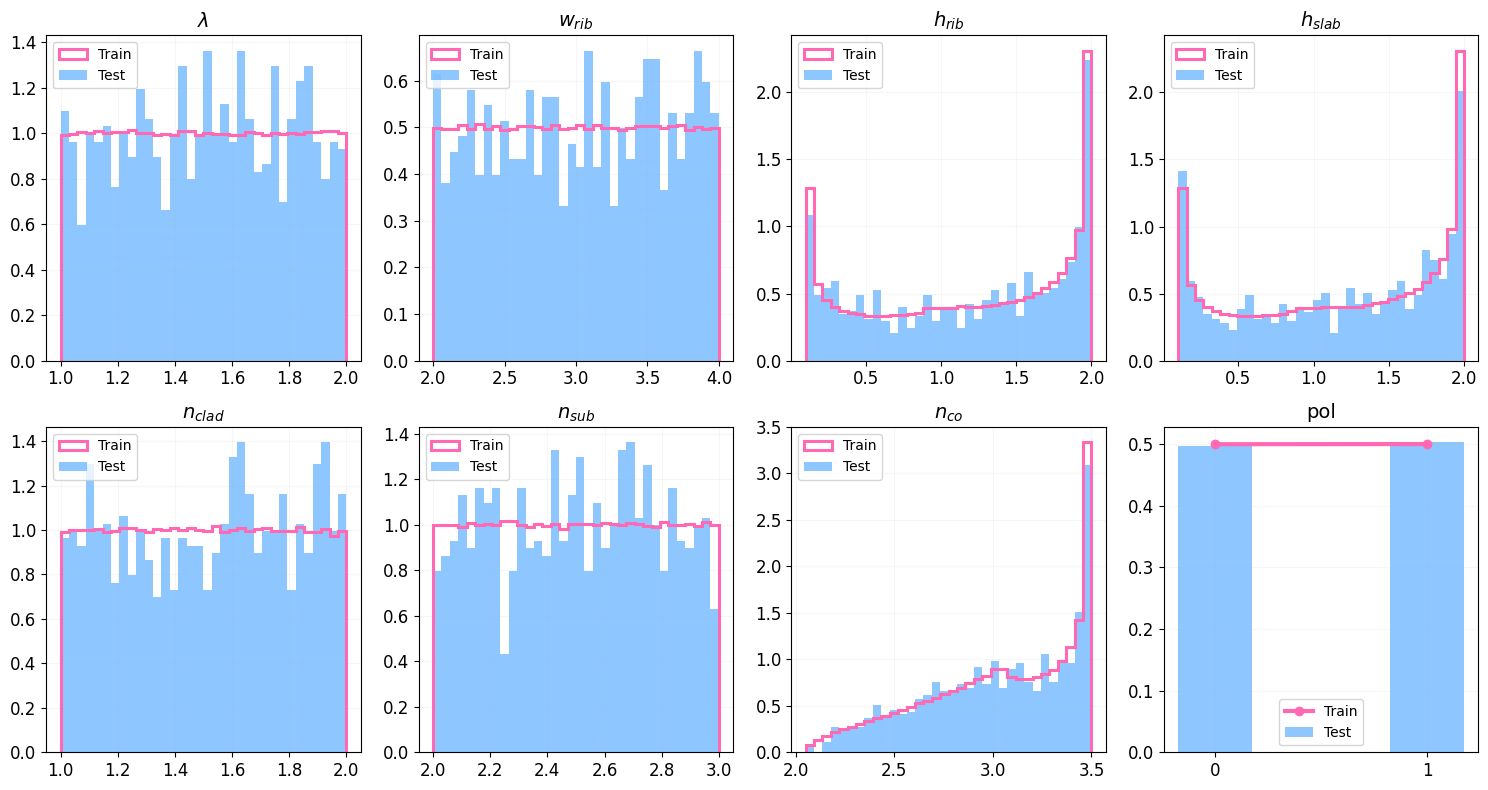

In [22]:
feature_names = [
    "$\lambda$",
    "$w_{rib}$",
    "$h_{rib}$",
    "$h_{slab}$",
    "$n_{clad}$",
    "$n_{sub}$",
    "$n_{co}$",
    "pol"
]

num_features = len(feature_names)
cols = 4
rows = int(np.ceil(num_features / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
axes = axes.flatten()

for i in range(num_features):
    ax = axes[i]
    
    if feature_names[i] == "pol":
        x = [0, 1]
        train_probs = [
            torch.mean((rib_features[:, i] == 0).to(float)),
            torch.mean((rib_features[:, i] == 1).to(float))
        ]
        test_probs = [
            torch.mean((rib_test_features[:, i] == 0).to(float)),
            torch.mean((rib_test_features[:, i] == 1).to(float)),
        ]
        ax.plot(
            x,
            train_probs,
            color='#FF69B4',
            linewidth=3,
            marker='o',
            label='Train'
        )
        ax.bar(
            x,
            test_probs,
            alpha=0.5,
            color='#1E90FF',
            width=0.35,
            label='Test'
        )
        ax.set_xticks([0, 1])

    else:

        all_vals = np.concatenate([
            rib_features[:, i],
            rib_test_features[:, i]
        ])

        bins = np.linspace(all_vals.min(), all_vals.max(), 35)
        ax.hist(
            rib_features[:, i].float(),
            bins=bins,
            density=True,
            histtype='step',
            linewidth=2.2,
            color='#FF69B4',
            label='Train'
        )
        ax.hist(
            rib_test_features[:, i].float(),
            bins=bins,
            density=True,
            alpha=0.5,
            color='#1E90FF',
            linewidth=0.4,
            label='Test'
        )

    ax.set_title(feature_names[i], fontsize=14)
    ax.grid(alpha=0.1)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.legend()
    ax.set_facecolor('white')
    
fig.patch.set_facecolor('white')

for i in range(num_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [3]:
torch.manual_seed(42)
train_dataset = ChannelDataset(n_dataset=640000, stochastic=False, device='cpu', dx=1/20, dy=1/20)
val_datasest = ChannelDataset(n_dataset=1024, stochastic=False, device='cpu', dx=1/20, dy=1/20)

In [4]:
channel_features = torch.tensor(train_dataset.dataset_features)
channel_features[:, 0] = 2 * np.pi / channel_features[:, 0]

channel_test_features = torch.tensor(val_datasest.dataset_features)
channel_test_features[:, 0] = 2 * np.pi / channel_test_features[:,0]

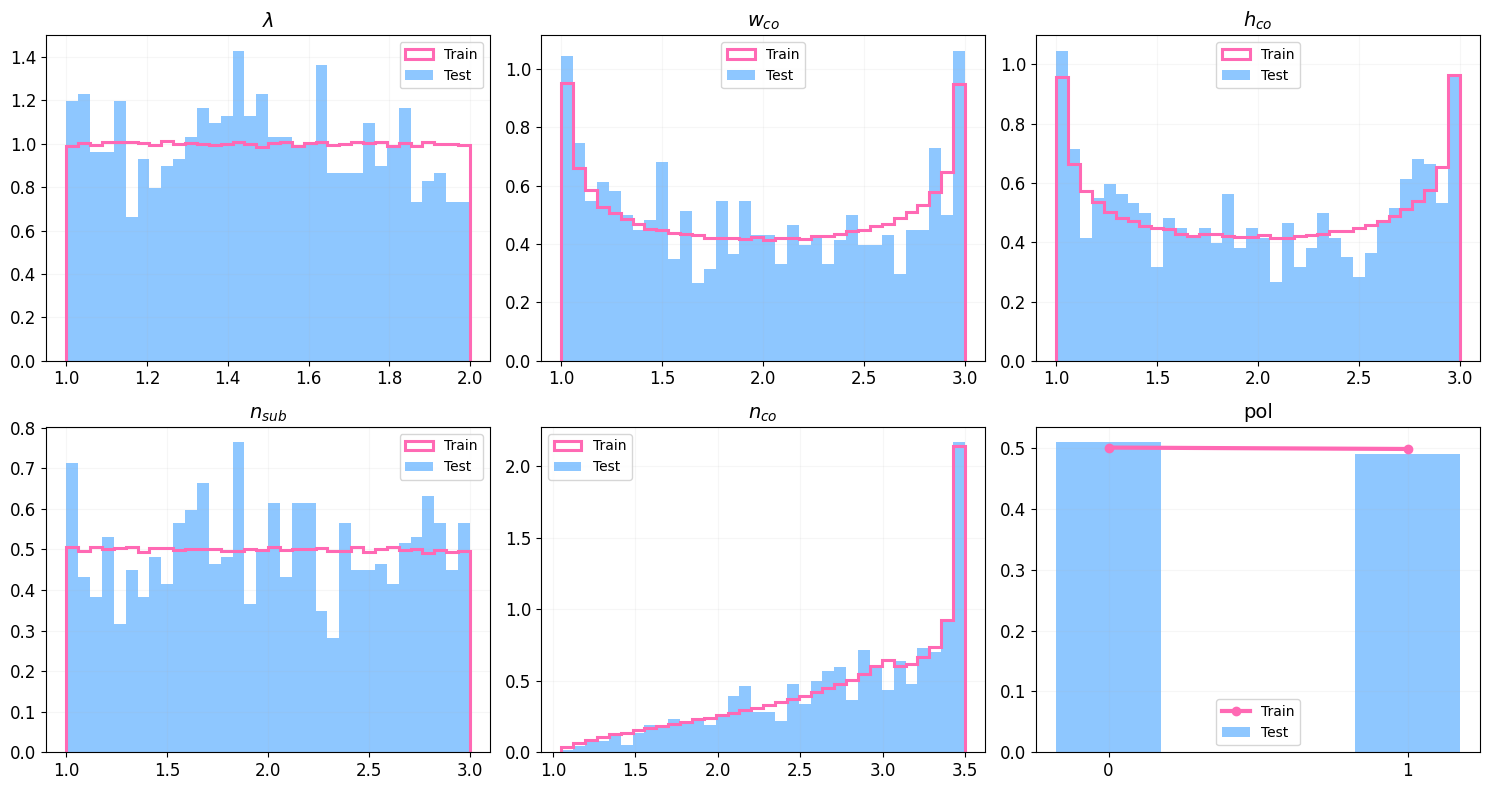

In [5]:
feature_names = [
    "$\lambda$",
    "$w_{co}$",
    "$h_{co}$",
    "$n_{sub}$",
    "$n_{co}$",
    "pol"
]

num_features = len(feature_names)
cols = 3
rows = int(np.ceil(num_features / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
axes = axes.flatten()

for i in range(num_features):
    ax = axes[i]
    
    if feature_names[i] == "pol":
        x = [0, 1]
        train_probs = [
            torch.mean((channel_features[:, i] == 0).to(float)),
            torch.mean((channel_features[:, i] == 1).to(float))
        ]
        test_probs = [
            torch.mean((channel_test_features[:, i] == 0).to(float)),
            torch.mean((channel_test_features[:, i] == 1).to(float)),
        ]
        ax.plot(
            x,
            train_probs,
            color='#FF69B4',
            linewidth=3,
            marker='o',
            label='Train'
        )
        ax.bar(
            x,
            test_probs,
            alpha=0.5,
            color='#1E90FF',
            width=0.35,
            label='Test'
        )
        ax.set_xticks([0, 1])

    else:

        all_vals = np.concatenate([
            channel_features[:, i],
            channel_test_features[:, i]
        ])

        bins = np.linspace(all_vals.min(), all_vals.max(), 35)
        ax.hist(
            channel_features[:, i].float(),
            bins=bins,
            density=True,
            histtype='step',
            linewidth=2.2,
            color='#FF69B4',
            label='Train'
        )
        ax.hist(
            channel_test_features[:, i].float(),
            bins=bins,
            density=True,
            alpha=0.5,
            color='#1E90FF',
            linewidth=0.4,
            label='Test'
        )

    ax.set_title(feature_names[i], fontsize=14)
    ax.grid(alpha=0.1)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.legend()
    ax.set_facecolor('white')
    
fig.patch.set_facecolor('white')

for i in range(num_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()